In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install open_clip_torch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import open_clip
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00


In [3]:
# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPUs available:", torch.cuda.device_count())

BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-5
NUM_CLASSES = 100
EPS = 1e-8
FLATNESS_LAMBDA = 30

selected_classes = list(range(NUM_CLASSES))

GPUs available: 2


In [4]:
# ---------------- CLIP MODEL ----------------
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
model = model.to(device)

class CLIPImageEncoder(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip = clip_model

    def forward(self, x):
        return self.clip.encode_image(x)

image_encoder = CLIPImageEncoder(model).to(device)

if torch.cuda.device_count() > 1:
    print("Using DataParallel")
    image_encoder = nn.DataParallel(image_encoder)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Using DataParallel


In [5]:
# ---------------- TRANSFORMS ----------------
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    preprocess
])

transform_clean = preprocess

In [6]:
# ---------------- DATASET FILTER ----------------
def filter_dataset(dataset, selected_classes):
    targets = np.array(dataset.targets)
    mask = np.isin(targets, selected_classes)

    dataset.data = dataset.data[mask]
    dataset.targets = targets[mask].tolist()

    label_map = {cls: i for i, cls in enumerate(selected_classes)}
    dataset.targets = [label_map[t] for t in dataset.targets]

    return dataset

In [7]:
# ---------------- DATASETS ----------------
train_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=False, download=True, transform=transform_clean
)

train_eval_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=False, transform=transform_clean
)

train_dataset = filter_dataset(train_dataset, selected_classes)
test_dataset = filter_dataset(test_dataset, selected_classes)
train_eval_dataset = filter_dataset(train_eval_dataset, selected_classes)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
train_eval_loader = DataLoader(train_eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

100%|██████████| 169M/169M [00:01<00:00, 86.8MB/s] 


In [8]:
# ---------------- CLASSIFIER ----------------
feature_dim = model.visual.output_dim

classifier = nn.Sequential(
    nn.Linear(feature_dim, 1024),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 100)
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW([
    {"params": model.parameters(), "lr": 1e-7},
    {"params": classifier.parameters(), "lr": 1e-3}
], weight_decay=1e-4)

In [9]:
# ---------------- HELPERS ----------------
def get_classifier_weight(classifier):
    if isinstance(classifier, nn.DataParallel):
        return classifier.module[-1].weight
    else:
        return classifier[-1].weight

In [10]:
# ---------------- METRICS ----------------
def compute_relative_flatness(features, logits, labels, classifier_weights):
    probs = torch.softmax(logits, dim=1)
    idx = torch.arange(len(labels), device=labels.device)
    p_y = probs[idx, labels]

    curvature_term = p_y * (1 - p_y)
    feat_norm_sq = torch.sum(features**2, dim=1)

    trace_estimate = torch.mean(feat_norm_sq * curvature_term)

    weight_norm_sq = torch.sum(classifier_weights**2)

    return (trace_estimate / (weight_norm_sq + EPS)).item()


def compute_nc_metrics(features, labels, classifier_weights):
    features = features.cpu().numpy()
    labels = labels.cpu().numpy()
    W = classifier_weights.detach().cpu().numpy()

    K = len(np.unique(labels))

    class_means = []
    for k in range(K):
        class_k = features[labels == k]
        mu_k = np.mean(class_k, axis=0)
        class_means.append(mu_k)

    class_means = np.array(class_means)
    overall_mean = np.mean(features, axis=0)

    Sw = 0.0
    for k in range(K):
        class_k = features[labels == k]
        mu_k = class_means[k]
        Sw += np.sum((class_k - mu_k) ** 2)

    Sb = np.sum((class_means - overall_mean) ** 2)
    nc1 = Sw / (Sb + EPS)

    M = class_means - overall_mean
    M = M / (np.linalg.norm(M, axis=1, keepdims=True) + EPS)
    G = M @ M.T

    ETF = np.full((K, K), -1/(K-1))
    np.fill_diagonal(ETF, 1)

    nc2 = np.linalg.norm(G - ETF, ord='fro')

    W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + EPS)
    nc3 = np.linalg.norm(W_norm - M, ord='fro')

    return nc1, nc2, nc3

In [11]:
# ---------------- HISTORY ----------------
train_acc_hist = []
train_clean_acc_hist = []
test_acc_hist = []
flatness_hist = []

In [12]:
# ===================== ZERO-SHOT =====================
class_names = train_dataset.classes
selected_class_names = [class_names[i] for i in selected_classes]

prompts = [f"a photo of a {name}" for name in selected_class_names]
tokenizer = open_clip.get_tokenizer('ViT-B-32')
text_tokens = tokenizer(prompts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Zero-shot"):
        images, labels = images.to(device), labels.to(device)

        image_features = image_encoder(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_features.T
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n===== ZERO-SHOT =====")
print("Acc:", np.mean(np.array(all_preds) == np.array(all_labels)) * 100)

Zero-shot: 100%|██████████| 157/157 [00:25<00:00,  6.12it/s]


===== ZERO-SHOT =====
Acc: 62.150000000000006


In [13]:
# ===================== TRAIN LOOP =====================
for epoch in range(EPOCHS):

    # -------- TRAIN (AUGMENTED) --------
    model.train()
    classifier.train()

    train_preds, train_labels_all = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [TRAIN]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        features = image_encoder(images)
        features = features / features.norm(dim=-1, keepdim=True)

        outputs = classifier(features)

        ce_loss = criterion(outputs, labels)

        # -------- FLATNESS REGULARIZER --------
        probs = torch.softmax(outputs, dim=1)
        p_y = probs[torch.arange(len(labels)), labels]

        curvature_term = p_y * (1 - p_y)
        feat_norm_sq = torch.sum(features**2, dim=1)

        flatness = torch.mean(curvature_term * feat_norm_sq)

        w = get_classifier_weight(classifier)
        flatness = flatness / (torch.sum(w**2) + EPS)

        loss = ce_loss - FLATNESS_LAMBDA * flatness

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

    train_aug_acc = np.mean(np.array(train_preds) == np.array(train_labels_all)) * 100
    train_acc_hist.append(train_aug_acc)

    print(f"\nTrain (Aug) Acc: {train_aug_acc:.2f}%")

    # -------- TRAIN (CLEAN EVAL) --------
    model.eval()
    classifier.eval()

    clean_preds, clean_labels = [], []

    with torch.no_grad():
        for images, labels in train_eval_loader:
            images, labels = images.to(device), labels.to(device)

            features = image_encoder(images)
            features = features / features.norm(dim=-1, keepdim=True)

            outputs = classifier(features)
            preds = outputs.argmax(dim=1)

            clean_preds.extend(preds.cpu().numpy())
            clean_labels.extend(labels.cpu().numpy())

    train_clean_acc = np.mean(np.array(clean_preds) == np.array(clean_labels)) * 100
    train_clean_acc_hist.append(train_clean_acc)

    print(f"Train (Clean) Acc: {train_clean_acc:.2f}%")

    # -------- TEST --------
    test_preds, test_labels_all = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            features = image_encoder(images)
            features = features / features.norm(dim=-1, keepdim=True)

            outputs = classifier(features)
            preds = outputs.argmax(dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_labels_all.extend(labels.cpu().numpy())

    test_acc = np.mean(np.array(test_preds) == np.array(test_labels_all)) * 100
    test_acc_hist.append(test_acc)

    print(f"Test Acc: {test_acc:.2f}%")

    # -------- FLATNESS (METRICS) --------
    flatness_hist.append(flatness.item())
    print(f"Flatness: {flatness.item():.6f}")

Epoch 1 [TRAIN]: 100%|██████████| 782/782 [06:17<00:00,  2.07it/s]


Train (Aug) Acc: 37.52%


Train (Clean) Acc: 67.82%
Test Acc: 67.79%
Flatness: 0.001517


Epoch 2 [TRAIN]: 100%|██████████| 782/782 [06:24<00:00,  2.03it/s]


Train (Aug) Acc: 61.99%


...


Train (Aug) Acc: 83.17%


Train (Clean) Acc: 89.73%
Test Acc: 84.64%
Flatness: 0.000055


Epoch 25 [TRAIN]: 100%|██████████| 782/782 [06:22<00:00,  2.04it/s]


Train (Aug) Acc: 83.50%


Train (Clean) Acc: 89.82%
Test Acc: 84.56%
Flatness: 0.000070


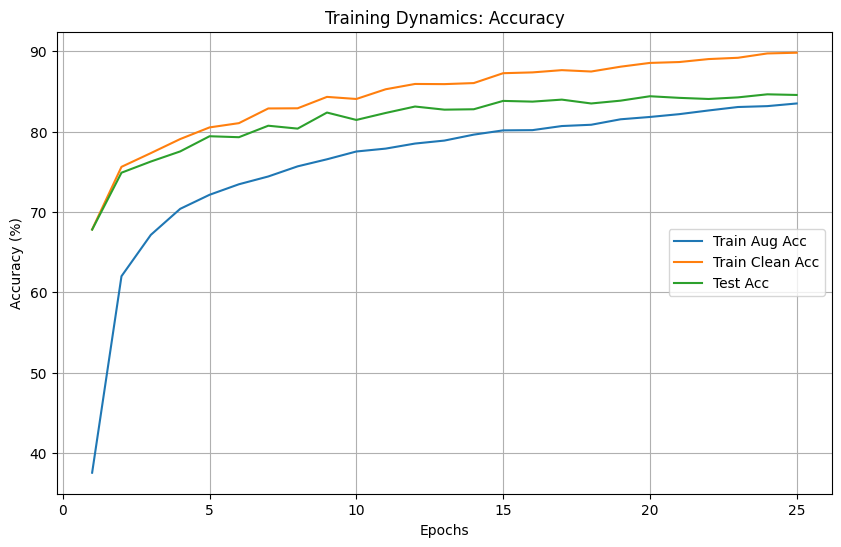

In [7]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 26))

# Accuracies
train_aug = [
    37.52, 61.99, 67.14, 70.38, 72.13, 73.44, 74.41, 75.67, 76.55, 77.52,
    77.88, 78.51, 78.88, 79.62, 80.15, 80.18, 80.69, 80.85, 81.53, 81.82,
    82.17, 82.63, 83.06, 83.17, 83.50
]

train_clean = [
    67.82, 75.61, 77.32, 79.07, 80.52, 81.05, 82.88, 82.90, 84.32, 84.06,
    85.27, 85.93, 85.91, 86.04, 87.27, 87.37, 87.65, 87.48, 88.08, 88.55,
    88.66, 89.03, 89.19, 89.73, 89.82
]

test_acc = [
    67.79, 74.88, 76.27, 77.53, 79.42, 79.30, 80.73, 80.37, 82.37, 81.45,
    82.32, 83.12, 82.73, 82.78, 83.82, 83.73, 83.98, 83.50, 83.85, 84.40,
    84.20, 84.06, 84.26, 84.64, 84.56
]

flatness = [
    0.001517, 0.001454, 0.000916, 0.000699, 0.000891, 0.000761, 0.000583,
    0.000488, 0.000357, 0.000275, 0.000187, 0.000175, 0.000231, 0.000190,
    0.000164, 0.000119, 0.000052, 0.000089, 0.000129, 0.000090, 0.000086,
    0.000110, 0.000114, 0.000055, 0.000070
]

# ===================== PLOTTING =====================

fig, ax1 = plt.subplots(figsize=(10, 6))

# Accuracy plots
ax1.plot(epochs, train_aug, label="Train Aug Acc")
ax1.plot(epochs, train_clean, label="Train Clean Acc")
ax1.plot(epochs, test_acc, label="Test Acc")

ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy (%)")
ax1.legend(loc="upper left")
ax1.grid(True)


# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 , loc="center right")

plt.title("Training Dynamics: Accuracy")
plt.show()

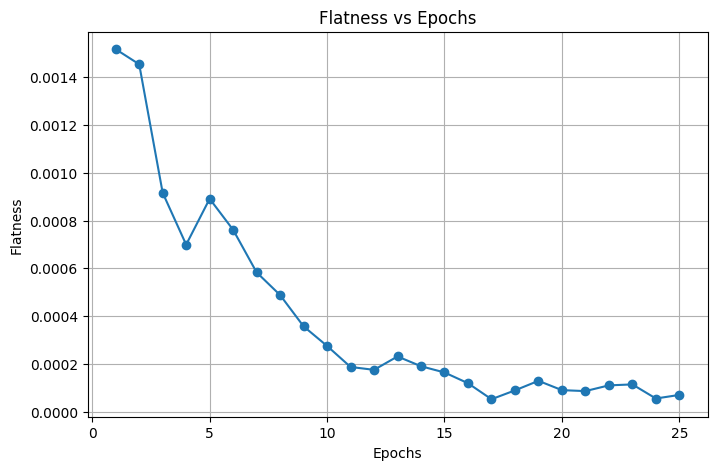

In [3]:
plt.figure(figsize=(8,5))

plt.plot(epochs, flatness, marker='o')

plt.xlabel("Epochs")
plt.ylabel("Flatness")
plt.title("Flatness vs Epochs")
plt.grid(True)

plt.show()